In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import namedtuple
Dataset = namedtuple('Dataset', ['X_train', 'X_test', 'y_train', 'y_test'])
Params = namedtuple('Params', ['min_samples_leaf', 'max_features', 'max_depth', 'force_label_split', 'oob_score'])

import rf_wrapper_functions


In [10]:
features = 30
similarity = 0.7 #Controls feature similarity between studies
intercept_sd = 1 #Changes the study mean
n = 150
n_studies = 4

X_train, X_test, y_train, y_test, X, y = rf_wrapper_functions.generate_dataset(
    n_datapoints_per_study = n, 
    n_studies = n_studies, 
    features = features, 
    similarity = similarity, 
    intercept_sd = intercept_sd,
    random_state=24
)

dataset = Dataset(X_train, X_test, y_train, y_test)

parameters = Params(1, "sqrt", 25, False, False) # [min_samples_leaf, max_features, max_depth, force_label_split, oob_score]

#forests, accuracy_score, source_score, source_size = rf_wrapper_functions.errorbars_depth_chart(n_seeds = 5, n_estimators = 250, depth = 12, dataset = dataset, parameters = parameters)

n= 20, f=20 best_depth=0, acc=0.93
n= 25, f=20 best_depth=0, acc=0.84
n= 30, f=20 best_depth=6, acc=0.76
n= 35, f=20 best_depth=4, acc=0.71
n= 40, f=20 best_depth=0, acc=0.66
n= 45, f=20 best_depth=0, acc=0.70
n= 50, f=20 best_depth=0, acc=0.83
n= 55, f=20 best_depth=0, acc=0.88
n= 60, f=20 best_depth=0, acc=0.81
n= 65, f=20 best_depth=0, acc=0.76
n= 70, f=20 best_depth=2, acc=0.71
n= 75, f=20 best_depth=1, acc=0.89
n= 80, f=20 best_depth=0, acc=0.92
n= 85, f=20 best_depth=0, acc=0.80
n= 90, f=20 best_depth=0, acc=0.84
n= 95, f=20 best_depth=2, acc=0.81
n=100, f=20 best_depth=1, acc=0.72
n=105, f=20 best_depth=0, acc=0.74
n=110, f=20 best_depth=11, acc=0.68
n=115, f=20 best_depth=0, acc=0.65
n=120, f=20 best_depth=0, acc=0.69
n=125, f=20 best_depth=1, acc=0.67
n=130, f=20 best_depth=0, acc=0.88
n=135, f=20 best_depth=0, acc=0.74
n=140, f=20 best_depth=5, acc=0.84
n=145, f=20 best_depth=1, acc=0.66
n= 20, f=25 best_depth=0, acc=0.75
n= 25, f=25 best_depth=0, acc=0.73
n= 30, f=25 best_de

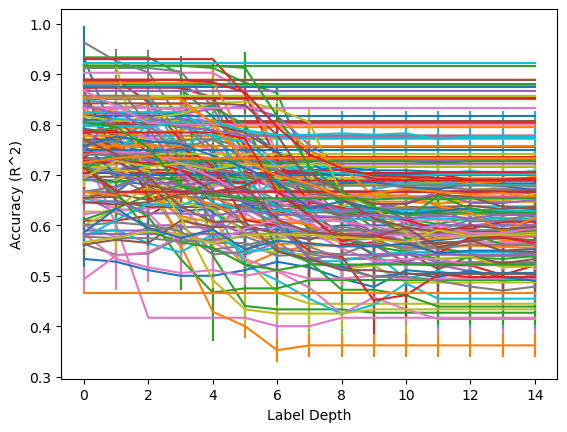

In [15]:
n_range = np.arange(20, 150, 5)
f_range = np.arange(20, 50, 5)

best_depth_grid    = np.full((len(n_range), len(f_range)), np.nan)
best_accuracy_grid = np.full((len(n_range), len(f_range)), np.nan)
    
#Number of Features
for j, f in enumerate(f_range):
    #Number of datapoints increasing by 5
    for i, n in enumerate(n_range):

        X_train, X_test, y_train, y_test, X, y = rf_wrapper_functions.generate_dataset(
            n_datapoints_per_study = n, 
            n_studies = 3, 
            features = f, 
            similarity = 0.8, 
            intercept_sd = 2,
            random_state = 24
        )

        dataset = Dataset(X_train, X_test, y_train, y_test)

        parameters = Params(1, "sqrt", 25, False, False) # [min_samples_leaf, max_features, max_depth, force_label_split, oob_score]

        forests, accuracy_score, source_score, source_size = rf_wrapper_functions.errorbars_depth_chart(
            n_seeds = 5, 
            n_estimators = 100, 
            depth = 15, 
            dataset = dataset, 
            parameters = parameters)
        
        best_depth = np.argmax(np.mean(accuracy_score, axis = 0))
        best_accuracy = np.mean(accuracy_score, axis = 0)[best_depth]

        best_depth_grid[i, j]    = best_depth
        best_accuracy_grid[i, j] = best_accuracy

        print(f"n={n:3d}, f={f:2d} best_depth={best_depth}, acc={best_accuracy:.2f}")

    
    
            
